### Assignment 05: Spectral Features for Time Series

**Imports and Libraries**

In [1]:
! pip install numpy matplotlib scipy PyWavelets

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pywt
from scipy.fft import fft, fftfreq

**I. Fourier Transform**

**1. Finding Hidden Frequencies**

**a. Compute the FFT and plot the single-sided amplitude spectrum.**

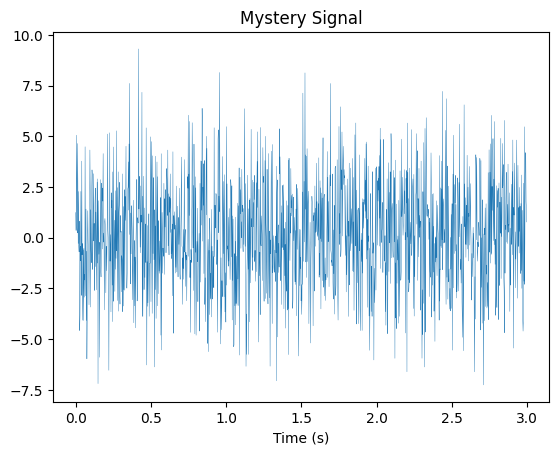

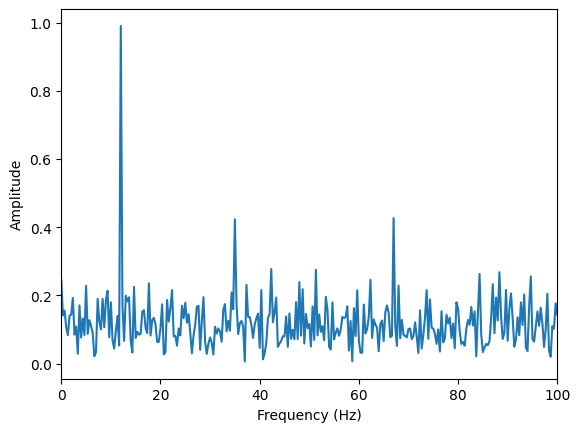

In [3]:
fs = 500 # Sampling rate (Hz)
t = np.arange(0, 3, 1/fs) # 3 seconds
np.random.seed(42)
# Mystery signal (3 sine waves + noise)
x = (1.0 * np.sin(2*np.pi*12*t) +
0.6 * np.sin(2*np.pi*35*t) +
0.4 * np.sin(2*np.pi*67*t) +
2.5 * np.random.randn(len(t)))
plt.plot(t, x, linewidth=0.3)
plt.title('Mystery Signal'); plt.xlabel('Time (s)')
plt.show()



N = len(x)
X = fft(x) # Apply FFT
freqs = fftfreq(N, 1/fs) # Frequency axis
amp = 2/N * np.abs(X[:N//2]) # Single-sided amplitude
plt.plot(freqs[:N//2], amp)
plt.xlabel('Frequency (Hz)'); plt.ylabel('Amplitude')
plt.xlim(0, 100)
plt.show()

**b. Three Peak Frequencies**

12 Hz, 35 Hz and 67 Hz

**c.**

**i. Why can you see these frequencies in the FFT even though the time-domain plot looks like noise?**

Even though the time plot looks noisy, the FFT adds up repeating patterns across the whole signal, so the hidden sinusoidal frequencies stand out as peaks.

**ii. What is the frequency resolution ∆f = fs/N of this FFT? (compute the number)**

500/1500 = 0.3333 Hz

**Problem 2. Filtering in the Frequency Domain**

**a. Create a bandpass filter in the frequency domain:** 

In [5]:
X = fft(x)
freqs_full = fftfreq(N, 1/fs)
# Create mask: 1 near the 3 frequencies, 0 elsewhere
mask = np.zeros(N)
for f_target in [12, 35, 67]:
    mask[np.abs(np.abs(freqs_full) - f_target) < 3] = 1
X_filtered = X * mask
x_clean = np.real(np.fft.ifft(X_filtered))

**Plot the original noisy signal and the filtered signal in two subplots (one above the other).**

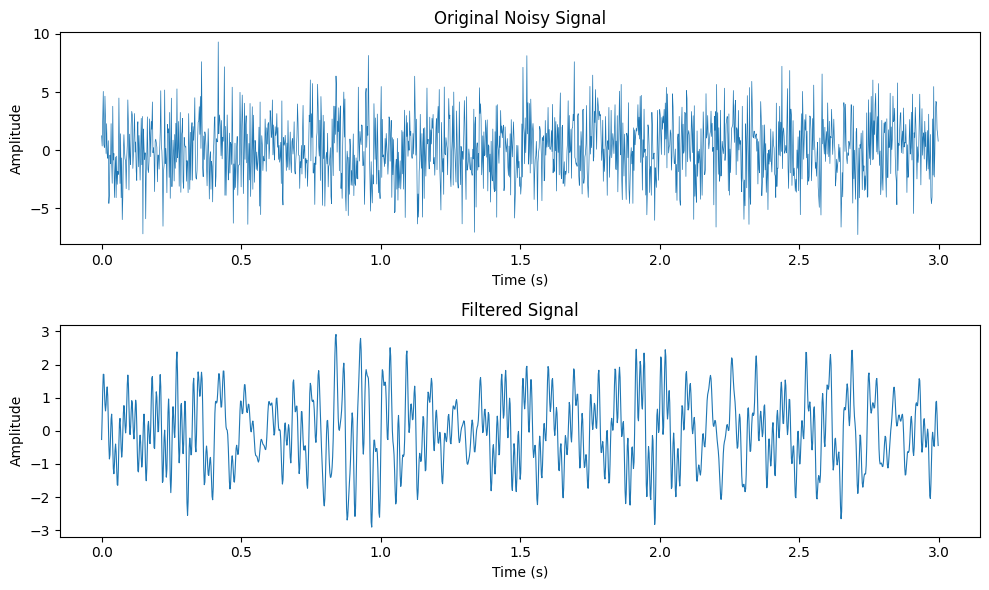

In [6]:
plt.figure(figsize=(10,6))

plt.subplot(2,1,1)
plt.plot(t, x, linewidth=0.5)
plt.title('Original Noisy Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.subplot(2,1,2)
plt.plot(t, x_clean, linewidth=0.8)
plt.title('Filtered Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()

In [8]:
# The true clean signal (no noise):
x_true = (1.0*np.sin(2*np.pi*12*t) + 0.6*np.sin(2*np.pi*35*t)
+ 0.4*np.sin(2*np.pi*67*t))
mse_before = np.mean((x - x_true)**2)
mse_after = np.mean((x_clean - x_true)**2)
print(f'MSE before: {mse_before:.4f}')
print(f'MSE after: {mse_after:.4f}')

MSE before: 6.1393
MSE after: 0.4794


**b.**

**MSE before:** 6.1393

**MSE after:** 0.4794

Filtering improved the signal by about:

**Absolute reduction:** 5.6599

About 12.8× lower MSE

**Problem 3: 2D FFT of an Image**

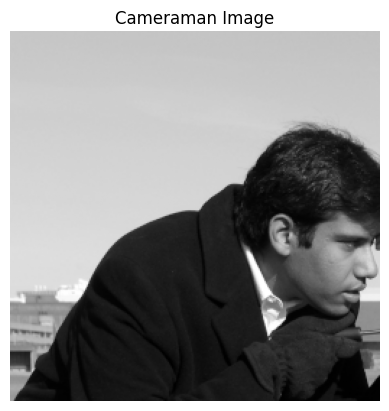

In [11]:
from scipy.fft import fft2, fftshift
from skimage import data
img = data.camera().astype(float)[:256, :256]
plt.imshow(img, cmap='gray')
plt.title('Cameraman Image'); plt.axis('off')
plt.show()

**b**

**The center of the spectrum represents the low spatial frequencies, which show the overall smooth structure and gradual brightness changes in the image. The edges represent the high spatial frequencies, which correspond to sharp edges, fine details, and rapid changes in intensity.**

**c**

**The bright cross pattern is caused by strong horizontal and vertical features in the image. These directional edges create high energy along the horizontal and vertical frequency axes.**

**PART II. Short-Time Fourier Transform**

**Problem 4: Why FFT Fails for Non-Stationary Signals**

In [12]:
fs = 500; t = np.arange(0, 6, 1/fs)
np.random.seed(42)
x = np.zeros_like(t)
x[t < 2] = np.sin(2*np.pi*10*t[t < 2])
x[(t >= 2) & (t < 4)] = np.sin(2*np.pi*40*t[(t >= 2) & (t < 4)])
x[t >= 4] = np.sin(2*np.pi*25*t[t >= 4])
x += 0.3 * np.random.randn(len(t))

**a. Plot the signal in the time domain. Can you visually see the three different frequencies?**

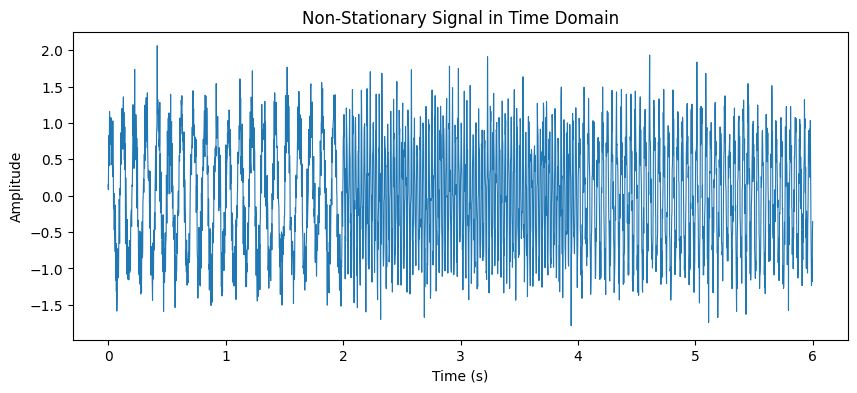

In [13]:
plt.figure(figsize=(10,4))
plt.plot(t, x, linewidth=0.8)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Non-Stationary Signal in Time Domain')
plt.show()

**No, we cannot see the three different frequencies clearly. You can tell the signal changes over time, but the noise makes it difficult to visually identify the three exact frequencies from the time-domain plot alone.**

**b. Compute the global FFT and plot the spectrum. Which frequencies do you see? Can the FFT tell you when each frequency occurs?**

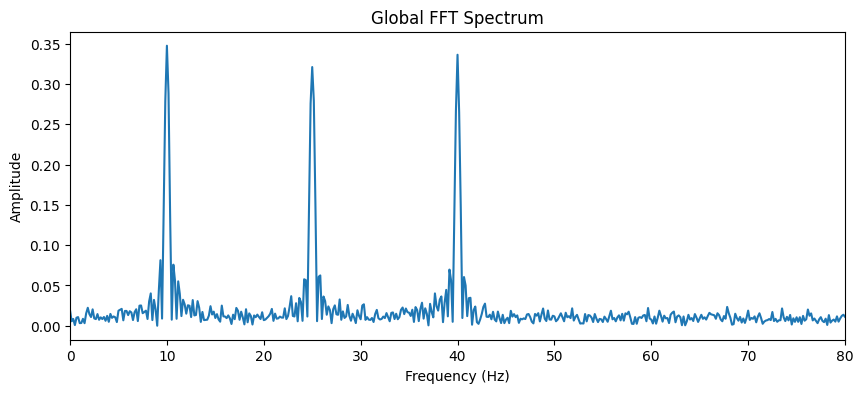

In [14]:
N = len(x)
X = fft(x)
freqs = fftfreq(N, 1/fs)
amp = 2/N * np.abs(X[:N//2])

plt.figure(figsize=(10,4))
plt.plot(freqs[:N//2], amp)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Global FFT Spectrum')
plt.xlim(0, 80)
plt.show()

**The global FFT shows peaks near 10 Hz, 25 Hz, and 40 Hz. However, the FFT cannot tell when each frequency occurs because it only shows the overall frequency content of the entire signal.**

**c. Answer in 2–3 sentences: Why does the FFT fail for this type of signal? What property of the signal does the FFT assume that is violated here? (Use the word “stationarity” in your answer.)**

The FFT fails here because this signal is non-stationary,i.e., its frequency changes over time. The FFT assumes stationarity, meaning the frequency content stays constant throughout the signal, so it mixes all three time-varying parts together into one spectrum.

**Problem 5: Spectrogram to the Rescue**

**a. Compute and display the spectrogram**

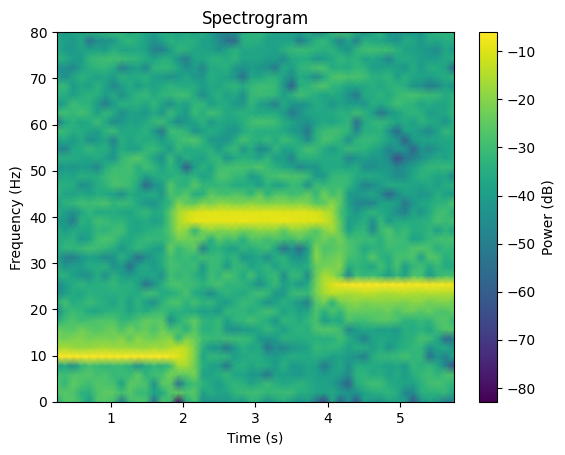

In [15]:
from scipy import signal
f, t_spec, Sxx = signal.spectrogram(x, fs, nperseg=256,
noverlap=200)
plt.pcolormesh(t_spec, f, 10*np.log10(Sxx + 1e-10),
shading='gouraud', cmap='viridis')
plt.ylim(0, 80)
plt.xlabel('Time (s)'); plt.ylabel('Frequency (Hz)')
plt.colorbar(label='Power (dB)')
plt.title('Spectrogram')
plt.show()

**b. From the spectrogram, fill in this table:**

Time segment 1 => 0-2s => 10 Hz

Time segment 2 => 2-4s => 40 Hz

Time segment 3 => 4-6s => 25 Hz

**c. Now try two different window sizes: nperseg=64 and nperseg=1024. Plot both spectrograms side by side and answer:**

**i. Which window gives better time resolution (sharper transitions between segments)?**

**ii. Which window gives better frequency resolution (thinner horizontal bands)?**

**iii. Why can’t you have both at the same time? (1 sentence, use “Heisenberg” or “tradeoff”)**

In [ ]:
# Small window
f1, t1, Sxx1 = signal.spectrogram(x, fs, nperseg=64, noverlap=50)

# Large window
f2, t2, Sxx2 = signal.spectrogram(x, fs, nperseg=1024, noverlap=900)

plt.figure(figsize=(12,5))

# ---- Plot 1: small window ----
plt.subplot(1,2,1)
plt.pcolormesh(t1, f1, 10*np.log10(Sxx1 + 1e-10),
               shading='gouraud', cmap='viridis')
plt.title('nperseg = 64 (Better Time Resolution)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.ylim(0, 80)

# ---- Plot 2: large window ----
plt.subplot(1,2,2)
plt.pcolormesh(t2, f2, 10*np.log10(Sxx2 + 1e-10),
               shading='gouraud', cmap='viridis')
plt.title('nperseg = 1024 (Better Frequency Resolution)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.ylim(0, 80)

plt.tight_layout()
plt.show()

**i. nperseg = 64**

**ii. nperseg = 1024**

**iii. This is a time-frequency tradeoff (Heisenberg uncertainty principle): improving time resolution makes frequency resolution worse, and improving frequency resolution makes time resolution worse.**
